## 0. Tiền xử lý dữ liệu

Import các thư viện chuyên dụng để xử lý dữ liệu khí hậu lưới và các công cụ kiểm định thống kê.

In [1]:
import os
import gc
import xarray as xr
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['axes.unicode_minus'] = False
folder_path = r'D:\clone\merged'

Xây dựng hàm xử lý dữ liệu nhiệt độ đất từ ERA5. Trong phân tích này, chúng ta nghiên cứu 4 tầng đất có độ sâu khác nhau:
- **Level 1 (7cm)**: Phản ứng nhanh với bức xạ mặt trời và biến động thời tiết ngắn hạn.
- **Level 2 (28cm)**: Phản ứng theo chu kỳ tuần.
- **Level 3 (100cm)**: Phản ứng theo chu kỳ tháng.
- **Level 4 (289cm)**: Tầng sâu, phản ứng rất chậm, thường đại diện cho tín hiệu khí hậu dài hạn.

Hàm thực hiện chuyển đổi từ Kelvin sang Celsius (°C), tính trung bình không gian và xác định các giá trị dị thường (Anomalies) để quan sát sự thẩm thấu nhiệt theo thời gian.

In [2]:
def load_and_aggregate_soil(soil_files, t2m_file):
    def preprocess(ds):
        if 'valid_time' in ds.coords: ds = ds.rename({'valid_time': 'time'})
        if 'expver' in ds.dims: ds = ds.mean(dim='expver')
        return ds.sortby('time')

    df_daily = pd.DataFrame()
    
    for i, file_name in enumerate(soil_files, 1):
        ds_soil = preprocess(xr.open_dataset(os.path.join(folder_path, file_name)))
        var_name = list(ds_soil.data_vars)[0]
        # Tính trung bình không gian và chuyển sang độ C
        soil_temp = (ds_soil[var_name] - 273.15).mean(dim=['latitude', 'longitude']).resample(time='1D').mean().compute()
        df_daily[f'soil_level_{i}'] = soil_temp.values
        ds_soil.close()
        gc.collect()

    ds_t2m = preprocess(xr.open_dataset(os.path.join(folder_path, t2m_file)))
    var_t2m = list(ds_t2m.data_vars)[0]
    t2m = (ds_t2m[var_t2m] - 273.15).mean(dim=['latitude', 'longitude']).resample(time='1D').mean().compute()
    df_daily['t2m'] = t2m.values
    df_daily.index = t2m.time.values
    ds_t2m.close()

    df_monthly = df_daily.resample('ME').mean()
    df_yearly = df_daily.resample('YS').mean()
    
    climatology = df_monthly.groupby(df_monthly.index.month).mean()
    
    df_monthly['month'] = df_monthly.index.month
    df_monthly['year'] = df_monthly.index.year
    
    df_anomaly = pd.DataFrame(index=df_monthly.index)
    df_anomaly['year'] = df_monthly['year']
    df_anomaly['month'] = df_monthly['month']
    
    soil_vars = ['soil_level_1', 'soil_level_2', 'soil_level_3', 'soil_level_4']
    for var in soil_vars:
        df_anomaly[var] = df_monthly[var] - df_monthly['month'].map(climatology[var])

    gc.collect()
    return df_daily, df_monthly, df_yearly, df_anomaly, climatology

Thực thi nạp dữ liệu và kiểm tra các chỉ số nhiệt độ đất và nhiệt độ không khí (`t2m`).

In [3]:
soil_files = [
    'soil_temperature_level_1_merged.nc',
    'soil_temperature_level_2_merged.nc',
    'soil_temperature_level_3_merged.nc',
    'soil_temperature_level_4_merged.nc'
]
t2m_file = '2m_temperature_merged.nc'

df_daily, df_monthly, df_yearly, df_anomaly, climatology = load_and_aggregate_soil(soil_files, t2m_file)
soil_vars = ['soil_level_1', 'soil_level_2', 'soil_level_3', 'soil_level_4']
layer_names = ["7cm", "28cm", "100cm", "289cm"]
depths = [0.035, 0.175, 0.640, 1.945]
colors = ['#d73027', '#fc8d59', '#91bfdb', '#4575b4']

df_daily.head()

,soil_level_1,soil_level_2,soil_level_3,soil_level_4,t2m
1980-01-01,23.697496,23.365433,23.078300,23.876762,23.688828
1980-01-02,23.644108,23.420876,23.136520,23.841618,23.533554
1980-01-03,23.837681,23.456753,23.225826,23.846254,23.554111
1980-01-04,23.823811,23.462595,23.340425,23.892406,22.988262
1980-01-05,23.252453,23.251949,23.438145,23.950239,21.940742


## 1. Sự lan truyền sóng nhiệt theo độ sâu đất & Dấu hiệu nóng lên

Sử dụng biểu đồ nhiệt (Heatmap) theo chiều đứng để quan sát cách nhiệt độ xâm nhập vào lòng đất:
- **Biểu đồ bên trái**: Trung bình 45 năm, cho thấy cấu trúc nhiệt độ ổn định.
- **Biểu đồ giữa và phải**: So sánh thập kỷ 1980 và thập kỷ gần đây (2015-2024). 
Sự thay đổi màu sắc sang tông đỏ đậm hơn ở tầng sâu trong thập kỷ gần đây là bằng chứng rõ rệt cho quá trình nóng lên toàn cầu đã thẩm thấu sâu vào lòng đất.

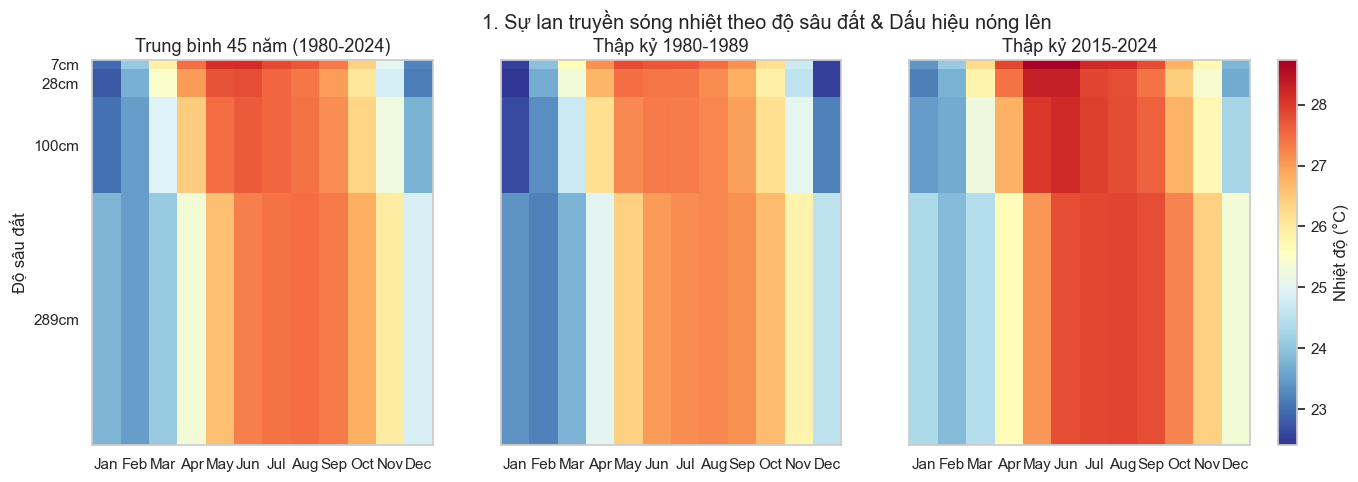

In [4]:

clim_80s = df_monthly.loc['1980':'1989'].groupby(df_monthly.loc['1980':'1989'].index.month).mean()
clim_recent = df_monthly.loc['2015':'2024'].groupby(df_monthly.loc['2015':'2024'].index.month).mean()

clim_vals_all = climatology[soil_vars].values.T
clim_vals_80s = clim_80s[soil_vars].values.T
clim_vals_recent = clim_recent[soil_vars].values.T

fig, axes = plt.subplots(1, 3, figsize=(18, 5), gridspec_kw={'width_ratios': [1, 1, 1]}, sharey=True)
vmin = np.min([clim_vals_80s, clim_vals_recent])
vmax = np.max([clim_vals_80s, clim_vals_recent])

titles = ['Trung bình 45 năm (1980-2024)', 'Thập kỷ 1980-1989', 'Thập kỷ 2015-2024']
data_list = [clim_vals_all, clim_vals_80s, clim_vals_recent]

plot_depths = [0, 0.07, 0.28, 1.00, 2.89]

for i, ax in enumerate(axes):
    c = ax.pcolormesh(range(1, 14), plot_depths, data_list[i], cmap="RdYlBu_r", shading="flat", vmin=vmin, vmax=vmax)
    ax.set_yticks(depths)
    ax.set_yticklabels(layer_names)
    ax.set_xticks(np.arange(1.5, 13.5))
    ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
    ax.set_title(titles[i], fontsize=13)
    if i == 0: ax.set_ylabel("Độ sâu đất")

axes[0].invert_yaxis()
cbar = fig.colorbar(c, ax=axes.ravel().tolist(), label="Nhiệt độ (°C)", pad=0.02)
plt.suptitle("1. Sự lan truyền sóng nhiệt theo độ sâu đất & Dấu hiệu nóng lên")
plt.show()

## 2. Chu kỳ mùa nhiệt độ đất: Độ trễ pha và suy giảm biên độ

Phân tích chu kỳ mùa của 4 tầng đất. Theo quy luật vật lý về truyền nhiệt trong môi trường xốp:
1. **Suy giảm biên độ**: Càng xuống sâu, chênh lệch nhiệt độ giữa mùa hè và mùa đông càng thu hẹp.
2. **Độ trễ pha (Phase Lag)**: Đỉnh nhiệt độ ở các tầng sâu luôn đến muộn hơn so với tầng mặt. Ví dụ: Khi tầng mặt đã bắt đầu hạ nhiệt vào mùa thu, tầng sâu 289cm có thể mới bắt đầu đạt đỉnh nhiệt độ của mùa hè.

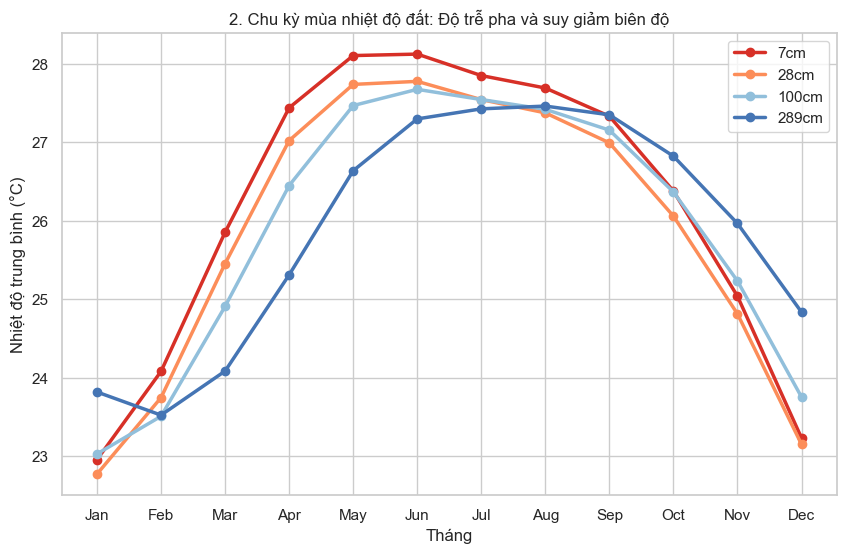

In [5]:
plt.figure(figsize=(10, 6))

for var, color, name in zip(soil_vars, colors, layer_names):
    plt.plot(climatology.index, climatology[var], marker='o', linewidth=2.5, color=color, label=name)

plt.title("2. Chu kỳ mùa nhiệt độ đất: Độ trễ pha và suy giảm biên độ")
plt.xlabel("Tháng")
plt.ylabel("Nhiệt độ trung bình (°C)")
plt.xticks(range(1, 13), ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
plt.legend()
plt.show()

## 3. Xu hướng nóng lên dài hạn tại các tầng đất

Phân tích tốc độ gia tăng nhiệt độ trung bình năm của từng tầng đất thông qua đường hồi quy tuyến tính. 

Việc tính toán độ dốc (slope) giúp định lượng tốc độ nóng lên theo thập kỷ (°C/decade). So sánh xu hướng giữa tầng mặt và các tầng sâu giúp xác định mức độ thẩm thấu của biến đổi khí hậu xuống lòng đất và khả năng lưu giữ nhiệt của các lớp thổ nhưỡng theo thời gian.

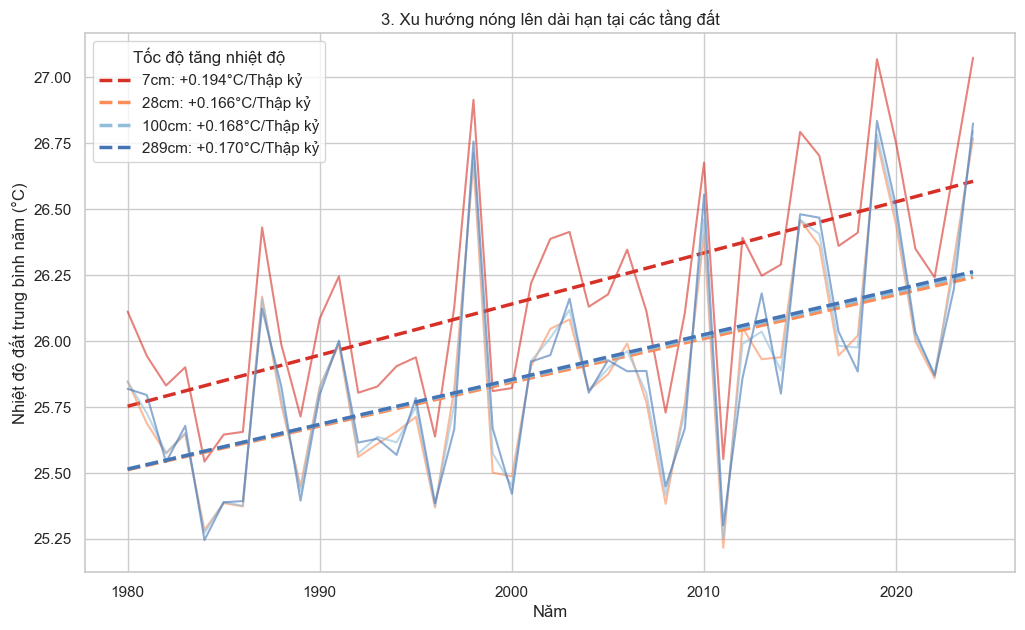

In [6]:
plt.figure(figsize=(12, 7))

for var, color, name in zip(soil_vars, colors, layer_names):
    y_vals = df_yearly[var].values
    x_vals = df_yearly.index.year.values
    
    # Hồi quy tuyến tính để tính trend
    slope, intercept, r_value, p_value, std_err = stats.linregress(x_vals, y_vals)
    trend_line = intercept + slope * x_vals
    
    plt.plot(x_vals, y_vals, color=color, alpha=0.6, linewidth=1.5)
    plt.plot(x_vals, trend_line, color=color, linestyle='--', linewidth=2.5, 
             label=f"{name}: +{slope*10:0.3f}°C/Thập kỷ")

plt.title("3. Xu hướng nóng lên dài hạn tại các tầng đất")
plt.xlabel("Năm")
plt.ylabel("Nhiệt độ đất trung bình năm (°C)")
plt.legend(title="Tốc độ tăng nhiệt độ")
plt.show()

## 4. Ma trận dị thường nhiệt độ đất: Sự thẩm thấu của các năm cực đoan

Hệ thống Heatmap này theo dõi cách các "dị thường" (ví dụ: một mùa hè nóng kỷ lục) lan truyền xuống dưới:
- Tầng mặt (Level 1) phản ánh các biến động "nhiễu" và tức thời.
- Các tầng sâu (Level 3, 4) lọc bỏ các biến động ngắn hạn, chỉ giữ lại các tín hiệu nhiệt độ bền vững. Những vệt màu đỏ kéo dài xuyên suốt các tháng ở tầng sâu cho thấy nhiệt độ cực đoan có thể tích lũy và tồn tại trong lòng đất rất lâu sau khi đợt nóng trên bề mặt kết thúc.

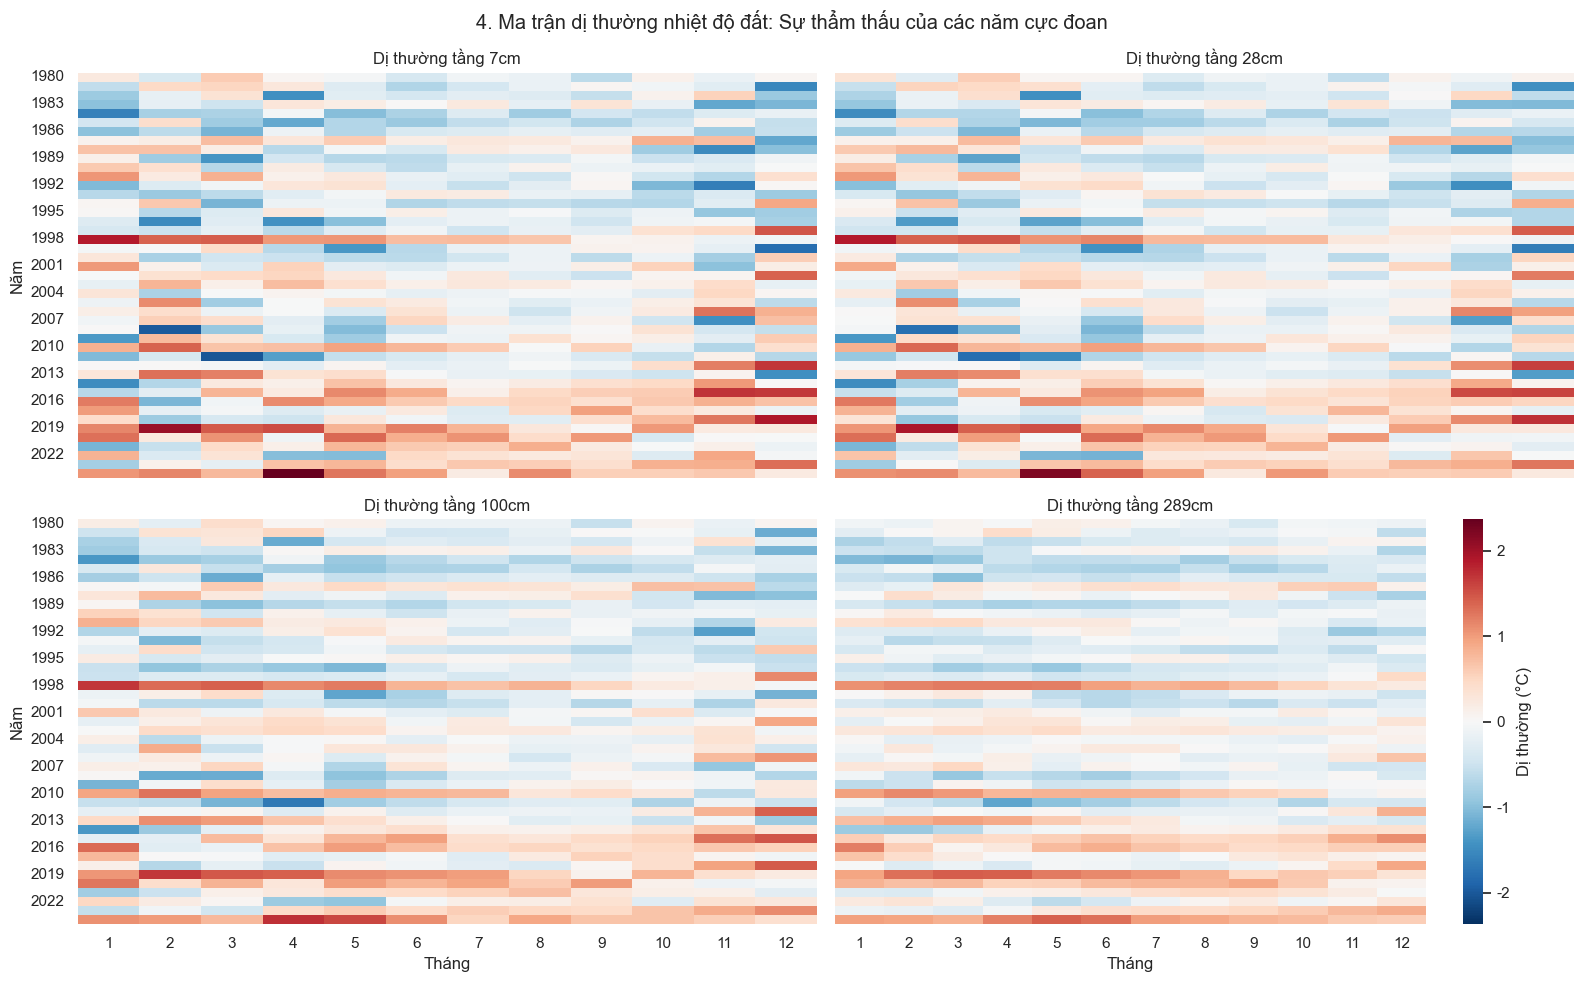

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharex=True, sharey=True)
axes = axes.flatten()

vmax_anom = np.abs(df_anomaly[soil_vars]).max().max()

for i, var in enumerate(soil_vars):
    pivot_table = df_anomaly.pivot(index='year', columns='month', values=var)
    sns.heatmap(pivot_table, ax=axes[i], cmap="RdBu_r", center=0, 
                vmin=-vmax_anom, vmax=vmax_anom, cbar=(i==3), 
                cbar_kws={'label': 'Dị thường (°C)'} if i==3 else None)
    
    axes[i].set_title(f"Dị thường tầng {layer_names[i]}")
    axes[i].set_ylabel("Năm" if i in [0, 2] else "")
    axes[i].set_xlabel("Tháng" if i in [2, 3] else "")

plt.suptitle("4. Ma trận dị thường nhiệt độ đất: Sự thẩm thấu của các năm cực đoan")
plt.tight_layout()
plt.show()

## 5. Lượng hóa Độ trễ pha nhiệt (Thermal Lag) theo Độ sâu

Sử dụng hồi quy tuyến tính để tính toán tốc độ truyền nhiệt. 
Hệ số góc (slope) cho biết mất bao nhiêu tháng để đỉnh nhiệt độ "di chuyển" xuống thêm 1 mét độ sâu. Đây là một chỉ số quan trọng để đánh giá tính chất nhiệt lý (Thermal properties) của thổ nhưỡng khu vực nghiên cứu.

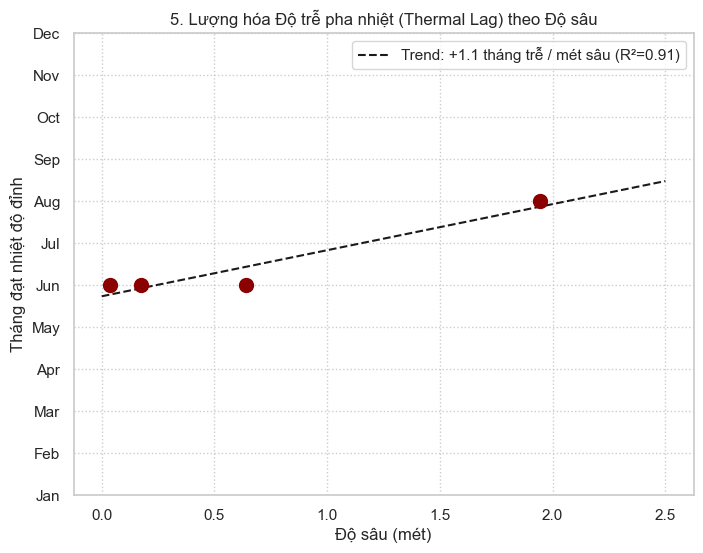

In [8]:
peak_months = climatology[soil_vars].idxmax().values

plt.figure(figsize=(8, 6))
plt.scatter(depths, peak_months, color='darkred', s=100, zorder=5)

slope_lag, int_lag, r_lag, _, _ = stats.linregress(depths, peak_months)
x_plot = np.linspace(0, 2.5, 100)
plt.plot(x_plot, int_lag + slope_lag * x_plot, 'k--', 
         label=f"Trend: +{slope_lag:.1f} tháng trễ / mét sâu (R²={r_lag**2:.2f})")

plt.title("5. Lượng hóa Độ trễ pha nhiệt (Thermal Lag) theo Độ sâu")
plt.xlabel("Độ sâu (mét)")
plt.ylabel("Tháng đạt nhiệt độ đỉnh")
plt.yticks(range(1, 13), ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
plt.legend()
plt.grid(True, linestyle=':')
plt.show()

## 6. Tương quan và Cross-Correlation giữa các tầng đất

- **Biểu đồ bên trái**: Tương quan tức thời. Các tầng gần nhau có tương quan cao, nhưng tầng 1 và tầng 4 thường có tương quan thấp nếu không xét đến độ trễ.
- **Biểu đồ bên phải**: Tìm độ trễ tối ưu thông qua Cross-correlation. Đỉnh của đường cong cho biết thời gian chính xác (tính bằng ngày) để một tín hiệu nhiệt từ bề mặt truyền xuống độ sâu gần 3 mét.

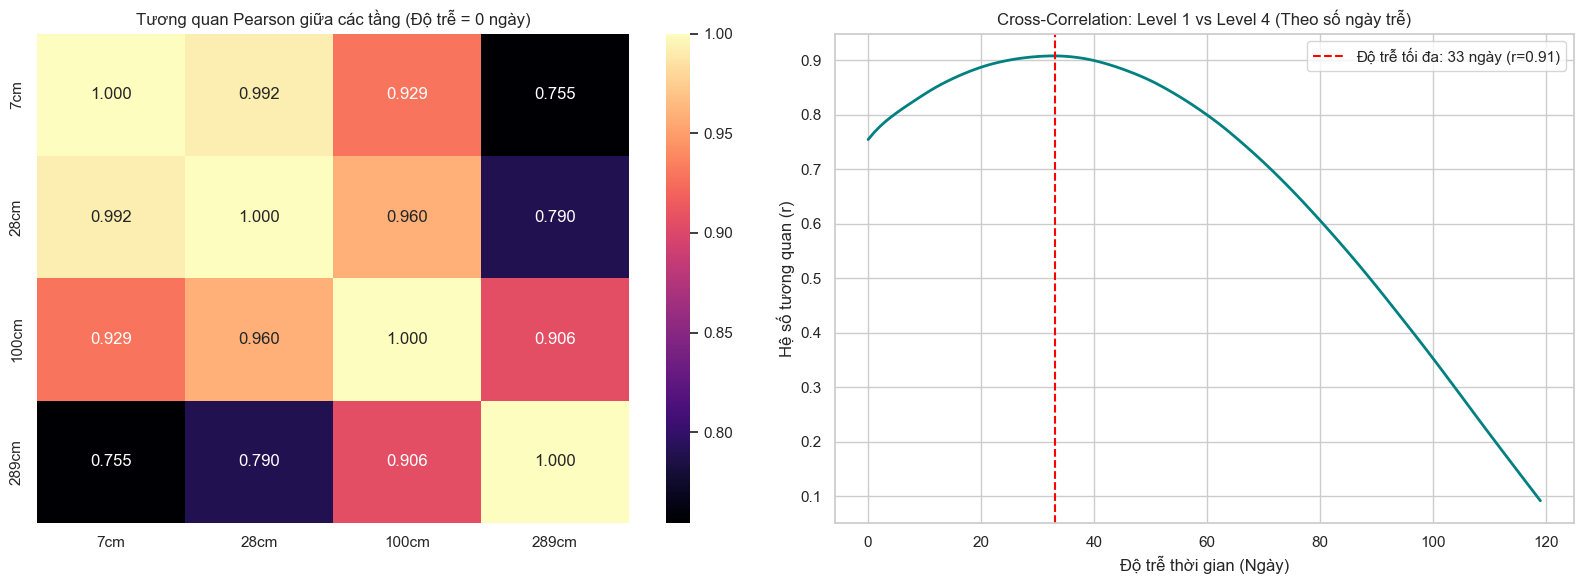

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

corr_matrix = df_daily[soil_vars].corr()
sns.heatmap(corr_matrix, annot=True, fmt=".3f", cmap="magma", ax=ax1, 
            xticklabels=layer_names, yticklabels=layer_names)
ax1.set_title("Tương quan Pearson giữa các tầng (Độ trễ = 0 ngày)")

lags = np.arange(0, 120, 1)
corrs = [df_daily['soil_level_1'].corr(df_daily['soil_level_4'].shift(-lag)) for lag in lags]

max_lag = lags[np.argmax(corrs)]
max_corr = np.max(corrs)

ax2.plot(lags, corrs, color='teal', linewidth=2)
ax2.axvline(max_lag, color='red', linestyle='--', label=f'Độ trễ tối đa: {max_lag} ngày (r={max_corr:.2f})')
ax2.set_title("Cross-Correlation: Level 1 vs Level 4 (Theo số ngày trễ)")
ax2.set_xlabel("Độ trễ thời gian (Ngày)")
ax2.set_ylabel("Hệ số tương quan (r)")
ax2.legend()

plt.tight_layout()
plt.show()

## 7. So sánh tương tác: Nhiệt độ bề mặt đất (Level 1) vs Nhiệt độ không khí

Phân tích mối quan hệ giữa nhiệt độ đất tầng mặt và không khí sát mặt đất:
- Khoảng tô màu đỏ/xanh thể hiện sự chênh lệch (Gradient) nhiệt độ.
- Gradient này quyết định chiều và cường độ của dòng nhiệt cảm (Sensible heat flux). Đất liên tục nóng hơn không khí (vùng đỏ chiếm ưu thế) nên mặt đất đang đóng vai trò là một nguồn nhiệt cho khí quyển bên trên.

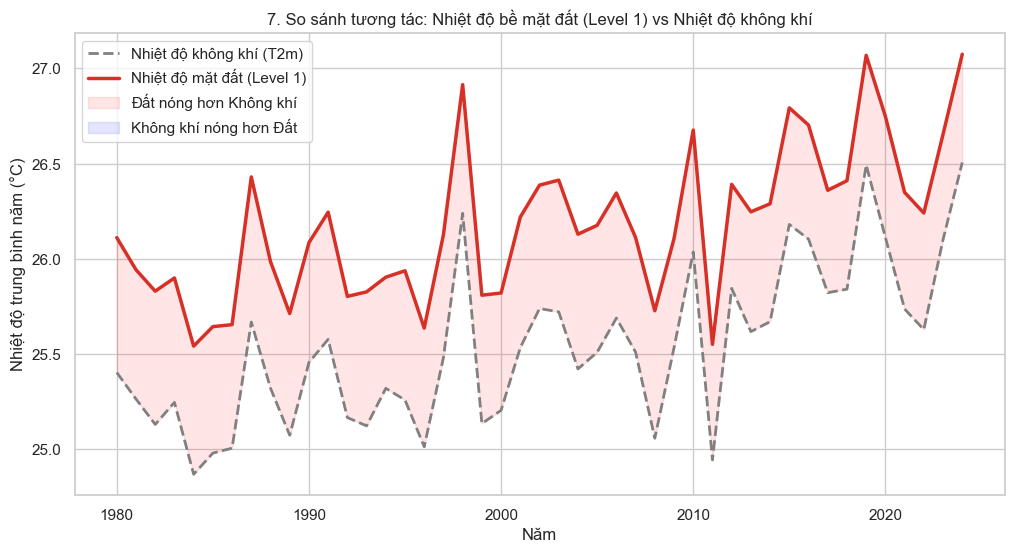

In [10]:
plt.figure(figsize=(12, 6))

plt.plot(df_yearly.index.year, df_yearly['t2m'], label='Nhiệt độ không khí (T2m)', color='gray', linewidth=2, linestyle='--')
plt.plot(df_yearly.index.year, df_yearly['soil_level_1'], label='Nhiệt độ mặt đất (Level 1)', color='#d73027', linewidth=2.5)

plt.fill_between(df_yearly.index.year, df_yearly['t2m'], df_yearly['soil_level_1'], 
                 where=(df_yearly['soil_level_1'] > df_yearly['t2m']), 
                 interpolate=True, color='red', alpha=0.1, label='Đất nóng hơn Không khí')
plt.fill_between(df_yearly.index.year, df_yearly['t2m'], df_yearly['soil_level_1'], 
                 where=(df_yearly['soil_level_1'] <= df_yearly['t2m']), 
                 interpolate=True, color='blue', alpha=0.1, label='Không khí nóng hơn Đất')

plt.title("7. So sánh tương tác: Nhiệt độ bề mặt đất (Level 1) vs Nhiệt độ không khí")
plt.xlabel("Năm")
plt.ylabel("Nhiệt độ trung bình năm (°C)")
plt.legend()
plt.show()

In [11]:
output_dir = r'D:\GitHub\climate-analysis-and-prediction\data\soil_temp'
os.makedirs(output_dir, exist_ok=True)

# ---- Main DataFrames ----
df_daily.to_parquet(f"{output_dir}/daily.parquet", compression='snappy')
df_monthly.to_parquet(f"{output_dir}/monthly.parquet", compression='snappy')
df_yearly.to_parquet(f"{output_dir}/yearly.parquet", compression='snappy')

# ---- Extra tables ----
df_anomaly.to_parquet(f"{output_dir}/anomaly.parquet", compression='snappy')
climatology.to_parquet(f"{output_dir}/climatology.parquet", compression='snappy')

print("✅ Saved soil temperature (all parquet)")

✅ Saved soil temperature (all parquet)
